In [67]:
import numpy as np
from dataclasses import dataclass
from typing import Tuple, Optional

In [68]:
@dataclass
class SMIBParameters:
  H: float = 5.0 #inertia constant
  D: float = 0.05 #damping coeff
  omega0: float = 2 * np.pi * 60 #synchronous speed
  Pm: float = 0.8 #mechanical power input (pu)
  Pmax: float = 2.1 #Max electrical power (pu)
  E: float = 1.05 #generator internal voltage (pu)
  V: float = 1.0 #infinite bus voltage (pu)

  @property
  def delta_eq(self) -> float:
    return np.arcsin(self.Pm / self.Pmax)

In [69]:
# This cell is no longer needed as delta_eq has been moved into SMIBParameters class.

In [70]:
from typing import Tuple, Optional

#equation solver usimg RK-4th order method.
class SwingEquationSolver:
  def __init__(self, params: SMIBParameters):
    self.params = params

#modeling power output according to fault scenarios where:
#when ff = 1.0 (normal), when ff = 0.0 (short circuit), when ff = 0-1 (partial faults)
  def electrical_power(self,
                       delta: float,
                       fault_factor: float = 1.0) -> float:
    return fault_factor * self.params.Pmax * np.sin(delta)

#definining the swing equation(rhs form)
  def swing_rhs(self, t: float,
                state: np.ndarray,
                fault_factor: float = 1.0) -> np.ndarray:
    delta, omega_deviated = state
    Pe = self.electrical_power(delta, fault_factor)
    d_delta = self.params.omega0 * omega_deviated # d_delta = omega, where omega is the absolute angular speed, and omega_deviated is (omega - omega0)
    d_omega_deviated = (self.params.omega0 / (2 * self.params.H)) * (self.params.Pm - Pe - self.params.D * omega_deviated)
    return np.array([d_delta, d_omega_deviated])

  def rk4_step(self, t: float,
               state: np.ndarray,
               dt: float,
               fault_factor: float = 1.0) -> np.ndarray:
    k1 = self.swing_rhs(t, state, fault_factor)
    k2 = self.swing_rhs(t + dt / 2, state + dt * k1 / 2, fault_factor)
    k3 = self.swing_rhs(t + dt / 2, state + dt * k2 / 2, fault_factor)
    k4 = self.swing_rhs(t + dt, state + dt * k3, fault_factor)
    return state + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

  def simulate(self, t_span: Tuple[float, float],
               dt: float = 0.001,
               delta0: Optional[float] = None,
               omega_deviated0: float = 0.0,
               fault_start: float = 0.0,
               fault_end: float = 0.0,
               fault_factor_pre: float = 1.0,
               fault_factor_fault: float = 0.0,
               fault_factor_post: float = 1.0) -> dict:
    t0, tf = t_span

    times = []
    delta_trajectory = []
    omega_deviated_trajectory = []

    if delta0 is None:
      delta0 = self.params.delta_eq

    current_state = np.array([delta0, omega_deviated0])

    t = t0
    while t <= tf:
      # Determine current fault factor based on time
      if t < fault_start:
        current_fault_factor = fault_factor_pre
      elif fault_start <= t < fault_end:
        current_fault_factor = fault_factor_fault
      else:
        current_fault_factor = fault_factor_post

      # Store current state
      times.append(t)
      delta_trajectory.append(current_state[0])
      omega_deviated_trajectory.append(current_state[1])

      # Take an RK4 step
      current_state = self.rk4_step(t, current_state, dt, current_fault_factor)
      t += dt

    # Append the last state as well, as the loop condition might cause it to be skipped
    if not times or abs(times[-1] - tf) > 1e-9: # Check if last point is missing
        times.append(tf)
        delta_trajectory.append(current_state[0])
        omega_deviated_trajectory.append(current_state[1])

    return {
        'time': np.array(times),
        'delta': np.array(delta_trajectory),
        'omega_deviated': np.array(omega_deviated_trajectory)
    }

In [71]:
# 1. Initialize SMIB Parameters
smib_params = SMIBParameters(
    H=5.0,
    D=0.05,
    omega0=2 * np.pi * 60,
    Pm=0.8,
    Pmax=2.1
)

# 2. Instantiate the SwingEquationSolver
solver = SwingEquationSolver(smib_params)

print(f"SMIB Parameters Initialized: {smib_params}")
print(f"Solver Initialized. Equilibrium Delta: {np.degrees(smib_params.delta_eq):.2f} degrees")

SMIB Parameters Initialized: SMIBParameters(H=5.0, D=0.05, omega0=376.99111843077515, Pm=0.8, Pmax=2.1, E=1.05, V=1.0)
Solver Initialized. Equilibrium Delta: 22.39 degrees


In [72]:
import torch

class PINNDataGenerator:
  """
  Generates all required datasets for PINN training.
  Three types of points:
  1. Collocation points: random t values where physics residual is enforced
  2. Data points: sparse measurements from RK4 simulation
  3. IC points: t=0 initial condition enforcement
  """
  def __init__(self, params: SMIBParameters, seed: int = 42):
    self.params = params
    self.solver = SwingEquationSolver(params) # Instantiate solver here
    np.random.seed(seed)
    torch.manual_seed(seed)

  def generate_reference_trajectory(
      self,
      fault_start: float = 0.1,
      fault_end: float = 0.2,
      t_total: float = 2.0,
      dt: float = 0.001
  ) -> dict:
    """Generate high-resolution reference trajectory using RK4."""
    t_span = (0.0, t_total)
    simulation_results = self.solver.simulate(
        t_span=t_span,
        dt=dt,
        delta0=self.params.delta_eq,
        omega_deviated0=0.0, # Starts at synchronous speed, so deviation is 0
        fault_start=fault_start,
        fault_end=fault_end,
        fault_factor_pre=1.0,
        fault_factor_fault=0.0, # Short circuit during fault
        fault_factor_post=1.0
    )

    # Convert omega_deviated to absolute omega (omega = omega_deviated + omega0)
    absolute_omega_trajectory = simulation_results['omega_deviated'] + self.params.omega0

    return {
        't': simulation_results['time'],
        'delta': simulation_results['delta'],
        'omega': absolute_omega_trajectory # Return absolute omega
    }

  def sample_training_data(
      self,
      trajectory: dict,
      n_collocation: int = 2000,
      n_data_points: int = 50,
      t_total: float = 2.0
  ) -> Dict[str, torch.Tensor]:
    """
    Sample training data from the reference trajectory.
    - Collocation points: Latin Hypercube sampling over [0, t_total]
    - Data points: sparse, uniformly sampled from trajectory
    """
    # -- Collocation points (no labels needed, only t) -------------
    # Latin Hypercube Sampling gives better coverage than uniform random
    intervals = np.linspace(0, t_total, n_collocation + 1)
    t_colloc = np.array([
        np.random.uniform(intervals[i], intervals[i+1])
        for i in range(n_collocation)
    ])

    # -- Data points (sparse measurements) -------------------------
    idx = np.linspace(0, len(trajectory['t'])-1, n_data_points, dtype=int)
    t_data = trajectory['t'][idx]
    d_data = trajectory['delta'][idx]
    w_data = trajectory['omega'][idx]

    # -- Initial condition ------------------------------------------
    t_ic = np.array([0.0])
    delta_ic = np.array([self.params.delta_eq])
    omega_ic = np.array([self.params.omega0]) # Absolute omega at t=0

    # Convert to tensors (requires_grad=True for collocation points)
    def to_tensor(arr, grad=False):
      t = torch.FloatTensor(arr).reshape(-1, 1)
      t.requires_grad_(grad)
      return t

    return {
        # Physics enforcement points
        't_colloc': to_tensor(t_colloc, grad=True),
        # Sparse measurement points
        't_data': to_tensor(t_data),
        'delta_data': to_tensor(d_data),
        'omega_data': to_tensor(w_data),
        # Initial condition point
        't_ic': to_tensor(t_ic),
        'delta_ic': to_tensor(delta_ic),
        'omega_ic': to_tensor(omega_ic),
    }

  def generate_test_grid(
      self, t_total: float = 2.0, n_points: int = 1000
  ) -> torch.Tensor:
    """Dense time grid for evaluation."""
    t = np.linspace(0, t_total, n_points)
    return torch.FloatTensor(t).reshape(-1, 1)

In [73]:
# 1. Instantiate the PINNDataGenerator
data_generator = PINNDataGenerator(params=smib_params, seed=42)

# Define simulation parameters for the reference trajectory
REF_FAULT_START = 1.0
REF_FAULT_END = 1.2
REF_T_TOTAL = 5.0
REF_DT = 0.0001 # Even finer resolution for reference

print(f"\nGenerating reference trajectory for t_total={REF_T_TOTAL}s, dt={REF_DT}s...")
reference_trajectory = data_generator.generate_reference_trajectory(
    fault_start=REF_FAULT_START,
    fault_end=REF_FAULT_END,
    t_total=REF_T_TOTAL,
    dt=REF_DT
)

print(f"Reference trajectory generated. Time points: {len(reference_trajectory['t'])}")
print(f"Sample (t, delta, omega) from reference:")
for i in [0, len(reference_trajectory['t']) // 2, -1]:
    t_val = reference_trajectory['t'][i]
    delta_val = np.degrees(reference_trajectory['delta'][i])
    omega_val = reference_trajectory['omega'][i]
    print(f"  t={t_val:.3f}s, delta={delta_val:.2f} deg, omega={omega_val:.2f} rad/s")


Generating reference trajectory for t_total=5.0s, dt=0.0001s...
Reference trajectory generated. Time points: 50001
Sample (t, delta, omega) from reference:
  t=0.000s, delta=22.39 deg, omega=376.99 rad/s
  t=2.500s, delta=345539.63 deg, omega=392.05 rad/s
  t=5.000s, delta=1198754.15 deg, omega=392.99 rad/s


In [74]:
# 2. Sample Training Data
N_COLLOCATION = 5000
N_DATA_POINTS = 100
TRAINING_T_TOTAL = 5.0

print(f"\nSampling training data: {N_COLLOCATION} collocation, {N_DATA_POINTS} data points...")
training_data = data_generator.sample_training_data(
    trajectory=reference_trajectory,
    n_collocation=N_COLLOCATION,
    n_data_points=N_DATA_POINTS,
    t_total=TRAINING_T_TOTAL
)

print("--- Training Data Shapes ---")
for key, value in training_data.items():
    print(f"{key}: {value.shape} (requires_grad={value.requires_grad})")

print("\n--- Initial Conditions Sample ---")
print(f"t_ic: {training_data['t_ic'].numpy().flatten()}")
print(f"delta_ic: {np.degrees(training_data['delta_ic'].numpy().flatten())[0]:.2f} degrees")
print(f"omega_ic: {training_data['omega_ic'].numpy().flatten()[0]:.2f} rad/s")

print("\n--- Sample Collocation Points ---")
print(f"t_colloc (first 5): {training_data['t_colloc'][:5].detach().numpy().flatten()}")

print("\n--- Sample Data Points (t, delta, omega) ---")
for i in range(5):
    t_val = training_data['t_data'][i].item()
    delta_val = np.degrees(training_data['delta_data'][i].item())
    omega_val = training_data['omega_data'][i].item()
    print(f"  t={t_val:.3f}s, delta={delta_val:.2f} deg, omega={omega_val:.2f} rad/s")


Sampling training data: 5000 collocation, 100 data points...
--- Training Data Shapes ---
t_colloc: torch.Size([5000, 1]) (requires_grad=True)
t_data: torch.Size([100, 1]) (requires_grad=False)
delta_data: torch.Size([100, 1]) (requires_grad=False)
omega_data: torch.Size([100, 1]) (requires_grad=False)
t_ic: torch.Size([1, 1]) (requires_grad=False)
delta_ic: torch.Size([1, 1]) (requires_grad=False)
omega_ic: torch.Size([1, 1]) (requires_grad=False)

--- Initial Conditions Sample ---
t_ic: [0.]
delta_ic: 22.39 degrees
omega_ic: 376.99 rad/s

--- Sample Collocation Points ---
t_colloc (first 5): [0.00037454 0.00195071 0.00273199 0.00359866 0.00415602]

--- Sample Data Points (t, delta, omega) ---
  t=0.000s, delta=22.39 deg, omega=376.99 rad/s
  t=0.051s, delta=22.39 deg, omega=376.99 rad/s
  t=0.101s, delta=22.39 deg, omega=376.99 rad/s
  t=0.152s, delta=22.39 deg, omega=376.99 rad/s
  t=0.202s, delta=22.39 deg, omega=376.99 rad/s


In [75]:
# 3. Generate Test Grid
N_TEST_POINTS = 1000
TEST_T_TOTAL = 5.0

print(f"\nGenerating test grid with {N_TEST_POINTS} points...")
test_grid = data_generator.generate_test_grid(t_total=TEST_T_TOTAL, n_points=N_TEST_POINTS)

print(f"Test grid shape: {test_grid.shape}")
print(f"Test grid (first 5): {test_grid[:5].numpy().flatten()}")
print(f"Test grid (last 5): {test_grid[-5:].numpy().flatten()}")


Generating test grid with 1000 points...
Test grid shape: torch.Size([1000, 1])
Test grid (first 5): [0.         0.005005   0.01001001 0.01501502 0.02002002]
Test grid (last 5): [4.97998   4.984985  4.9899898 4.994995  5.       ]


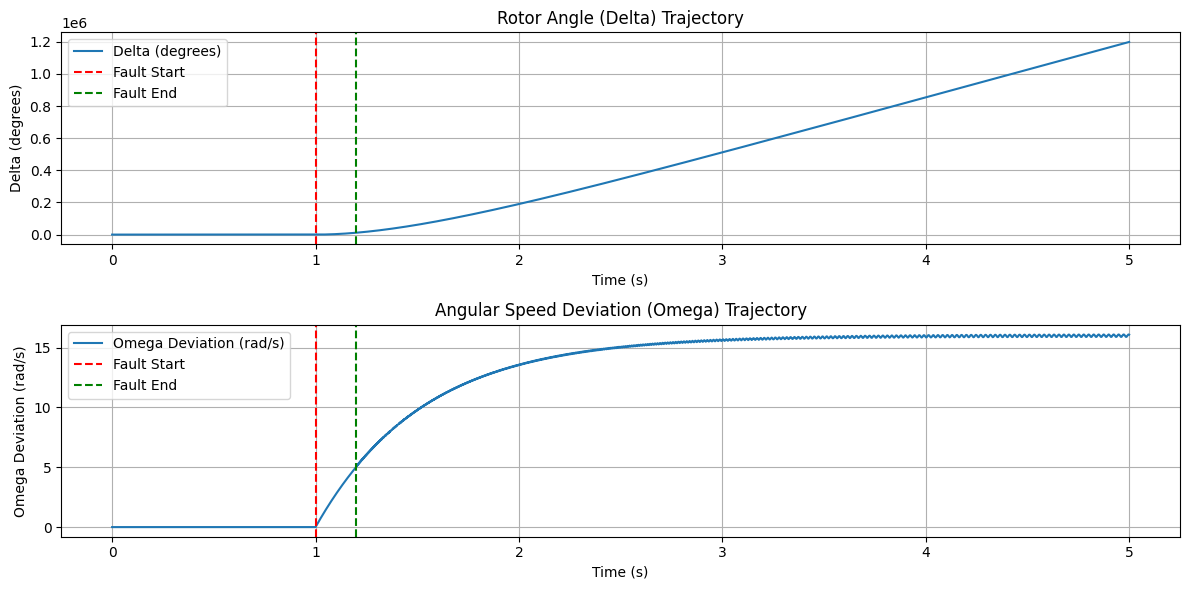

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_colloc, np.degrees(delta_trajectory), label='Delta (degrees)')
plt.axvline(x=fault_start, color='r', linestyle='--', label='Fault Start')
plt.axvline(x=fault_end, color='g', linestyle='--', label='Fault End')
plt.title('Rotor Angle (Delta) Trajectory')
plt.xlabel('Time (s)')
plt.ylabel('Delta (degrees)')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_colloc, omega_deviated_trajectory, label='Omega Deviation (rad/s)')
plt.axvline(x=fault_start, color='r', linestyle='--', label='Fault Start')
plt.axvline(x=fault_end, color='g', linestyle='--', label='Fault End')
plt.title('Angular Speed Deviation (Omega) Trajectory')
plt.xlabel('Time (s)')
plt.ylabel('Omega Deviation (rad/s)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [82]:
# Define new, much shorter, fault parameters for a truly stable scenario
TRULY_STABLE_FAULT_START = 1.0
TRULY_STABLE_FAULT_END = 1.01 # Very short fault duration: 0.01 seconds
TRULY_STABLE_T_TOTAL = 5.0
TRULY_STABLE_DT = 0.0001 # Fine resolution

print(f"\nGenerating reference trajectory for a truly stable scenario (fault duration: {TRULY_STABLE_FAULT_END - TRULY_STABLE_FAULT_START}s)...")

truly_stable_reference_trajectory = data_generator.generate_reference_trajectory(
    fault_start=TRULY_STABLE_FAULT_START,
    fault_end=TRULY_STABLE_FAULT_END,
    t_total=TRULY_STABLE_T_TOTAL,
    dt=TRULY_STABLE_DT
)

print(f"Truly stable reference trajectory generated. Time points: {len(truly_stable_reference_trajectory['t'])}")
print(f"Sample (t, delta, omega) from truly stable reference:")
for i in [0, len(truly_stable_reference_trajectory['t']) // 2, -1]:
    t_val = truly_stable_reference_trajectory['t'][i]
    delta_val = np.degrees(truly_stable_reference_trajectory['delta'][i])
    omega_val = truly_stable_reference_trajectory['omega'][i]
    print(f"  t={t_val:.3f}s, delta={delta_val:.2f} deg, omega={omega_val:.2f} rad/s")


Generating reference trajectory for a truly stable scenario (fault duration: 0.010000000000000009s)...
Truly stable reference trajectory generated. Time points: 50001
Sample (t, delta, omega) from truly stable reference:
  t=0.000s, delta=22.39 deg, omega=376.99 rad/s
  t=2.500s, delta=14.98 deg, omega=376.92 rad/s
  t=5.000s, delta=21.45 deg, omega=376.99 rad/s


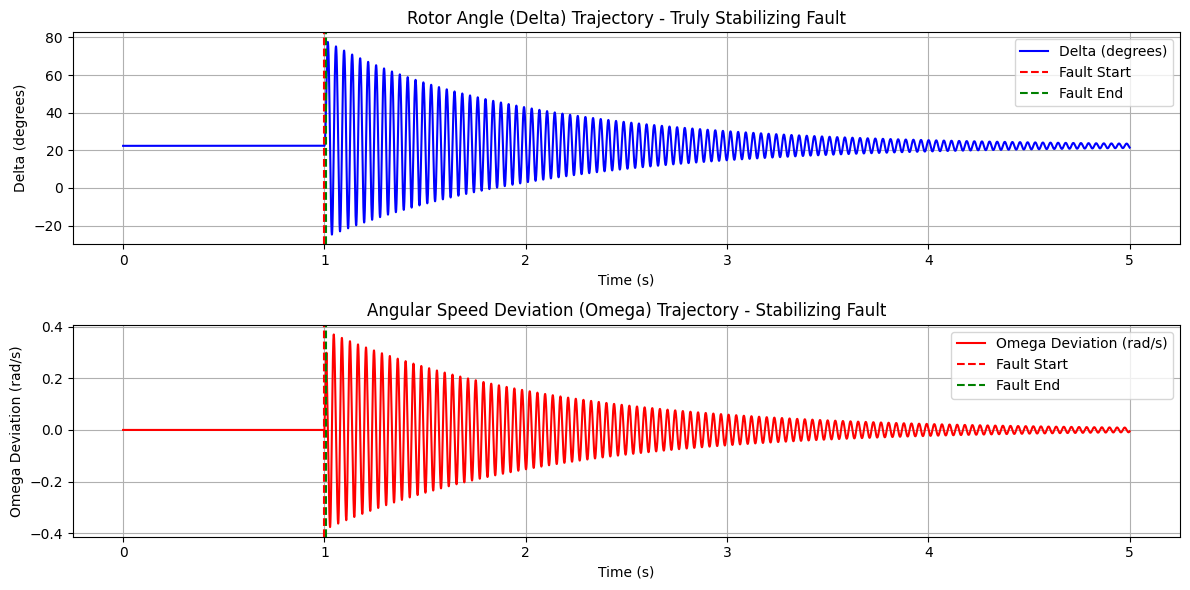

In [84]:
import matplotlib.pyplot as plt

# Using the truly_stable_reference_trajectory for this plot
t_colloc_truly_stable = truly_stable_reference_trajectory['t']
delta_trajectory_truly_stable = truly_stable_reference_trajectory['delta']
omega_abs_trajectory_truly_stable = truly_stable_reference_trajectory['omega']

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_colloc_truly_stable, np.degrees(delta_trajectory_truly_stable), 'b-', label='Delta (degrees)')
plt.axvline(x=TRULY_STABLE_FAULT_START, color='r', linestyle='--', label='Fault Start')
plt.axvline(x=TRULY_STABLE_FAULT_END, color='g', linestyle='--', label='Fault End')
plt.title('Rotor Angle (Delta) Trajectory - Stabilizing Fault')
plt.xlabel('Time (s)')
plt.ylabel('Delta (degrees)')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
# Convert absolute omega back to omega_deviated for this plot
omega_deviated_trajectory_truly_stable = omega_abs_trajectory_truly_stable - smib_params.omega0
plt.plot(t_colloc_truly_stable, omega_deviated_trajectory_truly_stable, 'r-', label='Omega Deviation (rad/s)')
plt.axvline(x=TRULY_STABLE_FAULT_START, color='r', linestyle='--', label='Fault Start')
plt.axvline(x=TRULY_STABLE_FAULT_END, color='g', linestyle='--', label='Fault End')
plt.title('Angular Speed Deviation (Omega) Trajectory - Stabilizing Fault')
plt.xlabel('Time (s)')
plt.ylabel('Omega Deviation (rad/s)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()